<a href="https://colab.research.google.com/github/NoorDataAnalyst/flyrank-ML-Internship/blob/main/notebooks/01_first_look_and_discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — Run it, then discover a real truth yourself

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # move from notebooks/ to the repo root

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [2]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [3]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [4]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?




In [5]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


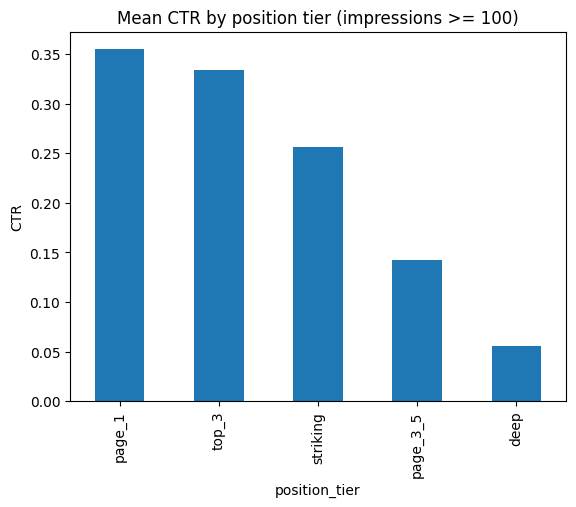

In [6]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [7]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

### Discovery D — Does the Relationship Between Search Volume and Impressions Change After Removing Zero-Impression Pages?

In [8]:
visible = df[df["impressions_90d"] > 0]
corr = visible["search_volume"].corr(visible["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d (impressions > 0): {corr:.3f}")
if abs(corr) < 0.3:
    print("Observation: The relationship remains weak even after removing pages with zero impressions.")
elif abs(corr) < 0.7:
    print("Observation: A moderate relationship is observed.")
else:
    print("Observation: A strong relationship is observed.")

Correlation between search_volume and impressions_90d (impressions > 0): 0.001
Observation: The relationship remains weak even after removing pages with zero impressions.


After removing pages with zero impressions, the correlation between search volume and impressions remained almost zero (0.001). This shows that keywords with higher search volume do not necessarily generate more impressions. Other SEO factors, such as ranking position, relevance, and competition, have a much greater impact on how many impressions a page receives.

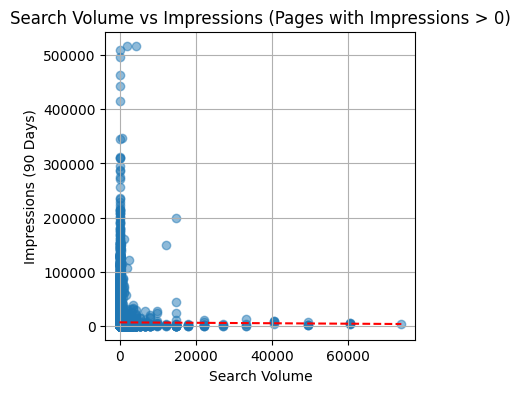

In [26]:
import matplotlib.pyplot as plt
import numpy as np

visible = df[df["impressions_90d"] > 0]

x = visible["search_volume"]
y = visible["impressions_90d"]

plt.figure(figsize=(4,4))
plt.scatter(x, y, alpha=0.5)

# Aggregate data for trend line to improve numerical stability
# This groups by search_volume and takes the mean impressions for each volume
aggregated_data = visible.groupby("search_volume")["impressions_90d"].mean().reset_index()
x_agg = aggregated_data["search_volume"]
y_agg = aggregated_data["impressions_90d"]

# Trend line
z = np.polyfit(x_agg, y_agg, 1)
p = np.poly1d(z)
plt.plot(x_agg, p(x_agg), color='red', linestyle='--') # Plot trend line with aggregated data

plt.xlabel("Search Volume")
plt.ylabel("Impressions (90 Days)")
plt.title("Search Volume vs Impressions (Pages with Impressions > 0)")

plt.grid(True)
plt.show()

###  Discovery E - Which content_type has the worst CTR at the same position tier?

In [10]:
# Average CTR for each Position Tier and Content Type
ctr_by_type = (
    df[df["impressions_90d"] >= 100]
    .groupby(["position_tier", "content_type"])["ctr"]
    .mean()
    .reset_index()
)

print("Average CTR by Position Tier and Content Type:\n")
print(ctr_by_type.round(4))
print("\nLowest CTR content type within each position tier:\n")

# Find lowest CTR for each position tier
worst_ctr = ctr_by_type.loc[
    ctr_by_type.groupby("position_tier")["ctr"].idxmin()
]

print(worst_ctr.round(4))

Average CTR by Position Tier and Content Type:

   position_tier        content_type     ctr
0           deep      feedly article  0.0440
1           deep     keyword article  0.0555
2         page_1  comparison article  0.1412
3         page_1      feedly article  0.9048
4         page_1     keyword article  0.3458
5       page_3_5  comparison article  0.0940
6       page_3_5      feedly article  0.1656
7       page_3_5     keyword article  0.1427
8       striking  comparison article  0.1474
9       striking      feedly article  0.3580
10      striking     keyword article  0.2559
11         top_3  comparison article  0.0000
12         top_3      feedly article  2.9000
13         top_3     keyword article  0.3104

Lowest CTR content type within each position tier:

   position_tier        content_type     ctr
0           deep      feedly article  0.0440
2         page_1  comparison article  0.1412
5       page_3_5  comparison article  0.0940
8       striking  comparison article  0.1474

Comparison articles consistently show the lowest average CTR across most position tiers, indicating they may have more opportunity for CTR optimization compared with other content types.

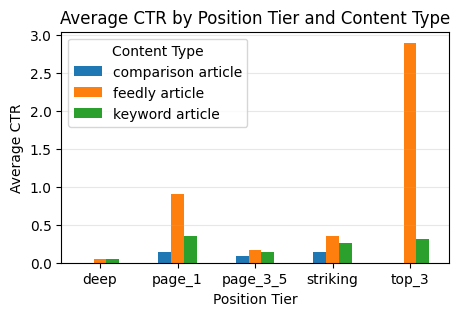

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

pivot = ctr_by_type.pivot(
    index="position_tier",
    columns="content_type",
    values="ctr"
)

pivot.plot(kind="bar", figsize=(5,3))

plt.title("Average CTR by Position Tier and Content Type")
plt.xlabel("Position Tier")
plt.ylabel("Average CTR")
plt.xticks(rotation=0)
plt.legend(title="Content Type")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Discover F(a) - Does content_age_days relate to trend_direction?

Median Content Age by Trend Direction:

trend_direction
down      216.0
flat      231.0
new       279.0
up        292.0
stable    300.0
Name: content_age_days, dtype: float64


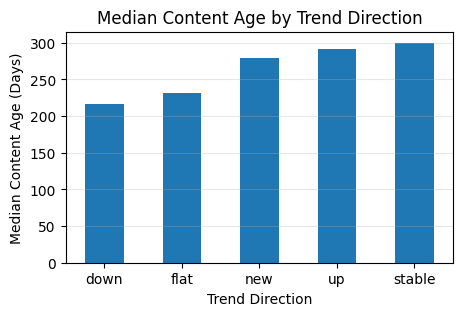

In [24]:
import matplotlib.pyplot as plt

# Calculate median content age for each trend group
age = (
    df.groupby("trend_direction")["content_age_days"]
      .median()
      .sort_values()
)

print("Median Content Age by Trend Direction:\n")
print(age.round(0))

# Visualization
plt.figure(figsize=(5,3))
age.plot(kind="bar")

plt.title("Median Content Age by Trend Direction")
plt.xlabel("Trend Direction")
plt.ylabel("Median Content Age (Days)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

The median content age varies slightly across the different trend direction groups. Stable pages have the highest median age (300 days), while down-trending pages have the lowest median age (216 days). However, the differences are relatively small, suggesting that content age alone does not appear to have a strong relationship with trend direction in this dataset. This is an observational finding and does not imply that content age causes pages to perform better or worse.

### Discovery F(b) - Does avg_position relate to ctr?

Correlation between Average Position and CTR: -0.073
Observation: Little or no relationship is observed between average position and CTR.


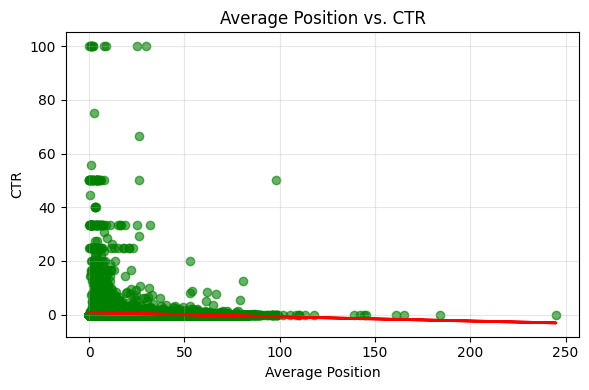

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlation
corr = df["avg_position"].corr(df["ctr"])

print(f"Correlation between Average Position and CTR: {corr:.3f}")

# Interpretation
if corr < -0.7:
    print("Observation: Better rankings (lower average position values) are strongly associated with higher CTR.")
elif corr < -0.3:
    print("Observation: A moderate negative relationship is observed between average position and CTR.")
else:
    print("Observation: Little or no relationship is observed between average position and CTR.")

# Data
x = df["avg_position"]
y = df["ctr"]

# Smaller figure
plt.figure(figsize=(6,4))

# Scatter plot (silver points)
plt.scatter(x, y, color="GREEN", alpha=0.6)

# Trend line (red)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), color="red", linewidth=2)

# Labels
plt.title("Average Position vs. CTR", fontsize=12)
plt.xlabel("Average Position")
plt.ylabel("CTR")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

The correlation between average position and CTR was -0.073, indicating little to no relationship between these variables in this dataset. Although the relationship is slightly negative, the correlation is very weak, suggesting that pages with better rankings did not consistently receive higher click-through rates. This is an observed relationship and does not imply causation.

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.